# Bivariate Analysis — Numerical vs Numerical 📊

> Analyzes the relationship between **two numerical variables**.

Examples: `Age vs Salary`, `Study_Hours vs Marks`

## Scatter Plot

Used to visualize the relationship between two numerical variables.

```python
import matplotlib.pyplot as plt

plt.scatter(df["X"], df["Y"])
plt.xlabel("X")
plt.ylabel("Y")
plt.show()
````

### Interpretation

* Upward pattern → Positive relationship
* Downward pattern → Negative relationship
* Random pattern → Little/no linear relationship

## Correlation

Measures the **strength and direction of a linear relationship**.

Range:

`-1 ≤ r ≤ +1`

* `+1` → Perfect positive
* `+0.7` → Strong positive
* `+0.4` → Moderate positive
* `0` → No linear relationship
* `-0.4` → Moderate negative
* `-0.7` → Strong negative
* `-1` → Perfect negative

```python
df["X"].corr(df["Y"])
```

## Pearson Correlation

Measures linear correlation.

```python
df["X"].corr(
    df["Y"],
    method="pearson"
)
```

## Correlation Matrix

Used to calculate correlations between multiple numerical variables.

```python
df.corr(numeric_only=True)
```

## Important

**Correlation ≠ Causation**

A strong correlation does not prove that one variable causes another.

Also, correlation mainly measures **linear relationships**, so always examine the scatter plot.

## Key Workflow

**Scatter Plot → Correlation → Correlation Matrix → Interpretation**

```
```


In [9]:
import pandas as pd

data = {
    "Experience": [
        1, 2, 2, 3, 3, 4, 4, 5, 5, 6,
        6, 7, 7, 8, 8, 9, 10, 11, 12, 14
    ],

    "Training_Hours": [
        5, 8, 6, 10, 12, 9, 15, 13, 18, 16,
        20, 17, 22, 19, 25, 23, 28, 30, 32, 35
    ],

    "Performance_Score": [
        52, 55, 58, 61, 63, 65, 67, 70, 71, 73,
        75, 77, 79, 80, 82, 84, 85, 87, 89, 92
    ],

    "Salary": [
        280, 300, 310, 330, 350, 370, 390, 420, 440, 470,
        490, 520, 550, 580, 610, 650, 700, 760, 830, 950
    ]
}

df = pd.DataFrame(data)

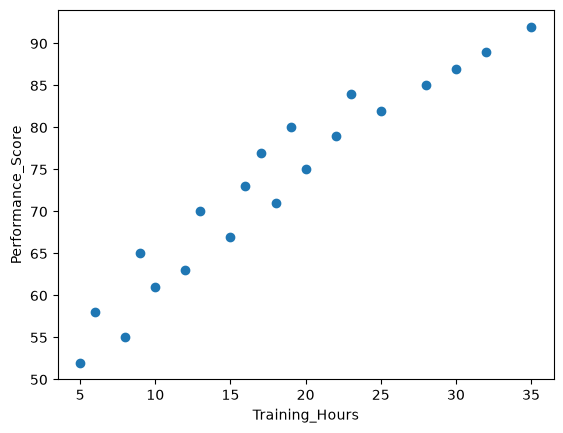

In [10]:
# scatter plots

import matplotlib.pyplot as plt

plt.scatter(df['Training_Hours'], df['Performance_Score'])
plt.xlabel('Training_Hours')
plt.ylabel('Performance_Score')
plt.show()

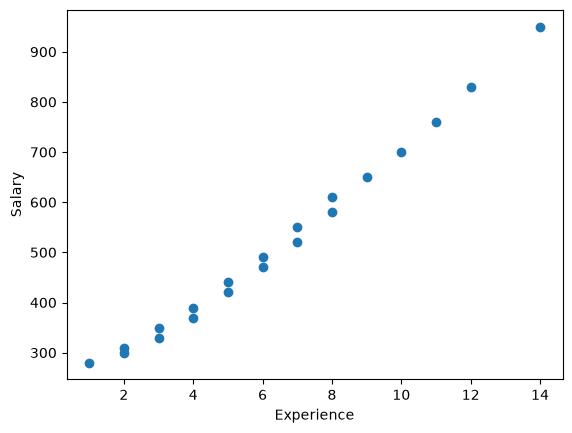

In [11]:
import matplotlib.pyplot as plt

plt.scatter(df['Experience'], df['Salary'])
plt.xlabel('Experience')
plt.ylabel('Salary')
plt.show()

In [12]:
# Correlation
df['Training_Hours'].corr(df['Performance_Score'])

np.float64(0.962852940598079)

In [13]:
df['Experience'].corr(df['Salary'])

np.float64(0.9942352236096602)

In [14]:
# Correlation Matrix

In [15]:
df.corr(numeric_only=True)

,Experience,Training_Hours,Performance_Score,Salary
Experience,1.000000,0.970677,0.974410,0.994235
Training_Hours,0.970677,1.000000,0.962853,0.972102
Performance_Score,0.974410,0.962853,1.000000,0.954125
Salary,0.994235,0.972102,0.954125,1.000000


In [16]:
# Pearson Correlation
# It measures the strength of a linear relationship.

df["Experience"].corr(df["Salary"], method="pearson")

np.float64(0.9942352236096602)

# Numerical vs Categorical

> Analyzes the relationship between one numerical and one categorical variable.

Examples: `Salary vs Department`, `Marks vs Gender`

## Main Goal

Check whether the numerical variable differs across categories.

## Group Statistics

### Mean

```python
df.groupby("Department")["Salary"].mean()
````

### Median

```python
df.groupby("Department")["Salary"].median()
```

### Summary Statistics

```python
df.groupby("Department")["Salary"].describe()
```

## Box Plot

Best for comparing numerical distributions across categories.

```python
import seaborn as sns

sns.boxplot(
    x="Department",
    y="Salary",
    data=df
)
```

Shows:

* Median
* Spread
* Distribution
* Outliers

## Bar Plot

Useful for comparing group means.

```python
df.groupby("Department")["Salary"].mean().plot(
    kind="bar"
)
```

or

```python
sns.barplot(
    x="Department",
    y="Salary",
    data=df
)
```

## Statistical Tests

### 2 Groups

Independent t-test → compare means

Mann–Whitney U → non-parametric alternative

### More than 2 Groups

ANOVA → compare means

Kruskal–Wallis → non-parametric alternative

## Important

Correlation is NOT used directly for numerical vs categorical variables.

Focus on:

**Group Statistics → Box Plot → Distribution → Interpretation**

And remember:

**Association ≠ Causation**

```
```


In [17]:
import pandas as pd

data = {
    "Department": [
        "IT","IT","IT","IT","IT",
        "HR","HR","HR","HR","HR",
        "Sales","Sales","Sales","Sales","Sales",
        "Finance","Finance","Finance","Finance","Finance",
        "IT","HR","Sales","Finance","IT"
    ],

    "Job_Level": [
        "Junior","Junior","Mid","Senior","Senior",
        "Junior","Mid","Mid","Senior","Senior",
        "Junior","Junior","Mid","Senior","Senior",
        "Junior","Mid","Mid","Senior","Senior",
        "Mid","Junior","Mid","Senior","Senior"
    ],

    "Experience": [
        1,2,4,8,10,
        1,4,5,9,12,
        1,3,5,8,11,
        2,4,6,9,13,
        5,2,6,10,12
    ],

    "Salary": [
        300,330,450,700,780,
        280,400,420,600,650,
        290,340,480,620,720,
        310,430,500,680,800,
        470,300,510,700,820
    ]
}

df = pd.DataFrame(data)

In [19]:
df.groupby('Department')['Salary'].describe()

,count,mean,std,min,25%,50%,75%,max
Department,,,,,,,,
Finance,6.0,570.000000,186.547581,310.0,447.5,590.0,695.0,800.0
HR,6.0,441.666667,152.894299,280.0,325.0,410.0,555.0,650.0
IT,7.0,550.000000,214.320632,300.0,390.0,470.0,740.0,820.0
Sales,6.0,493.333333,162.931478,290.0,375.0,495.0,592.5,720.0


<Axes: xlabel='Department', ylabel='Salary'>

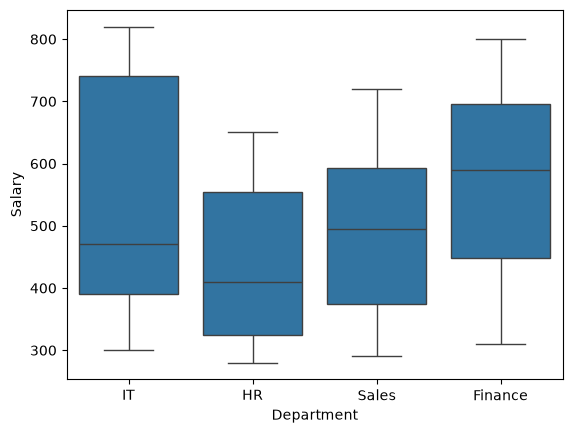

In [20]:
import seaborn as sns

sns.boxplot(x = 'Department', y = 'Salary', data = df)

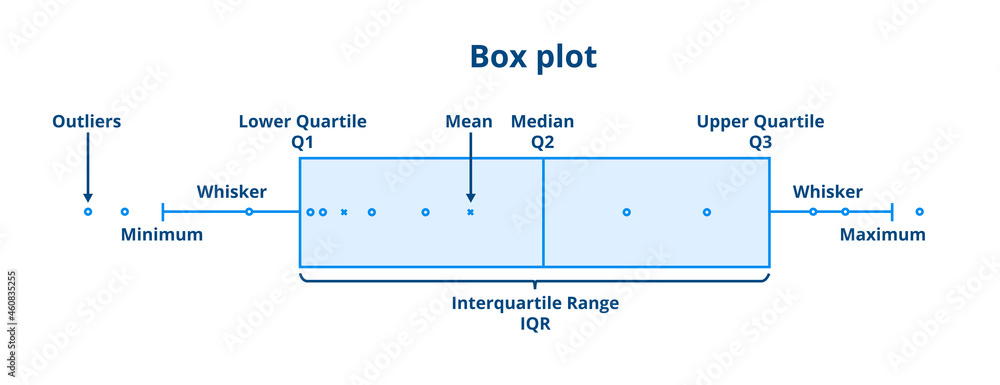

<Axes: xlabel='Department', ylabel='Salary'>

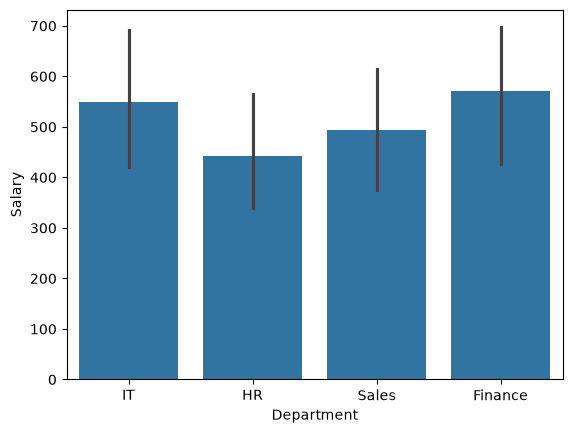

In [21]:
sns.barplot(x="Department", y="Salary", data=df)

<Axes: xlabel='Job_Level', ylabel='Salary'>

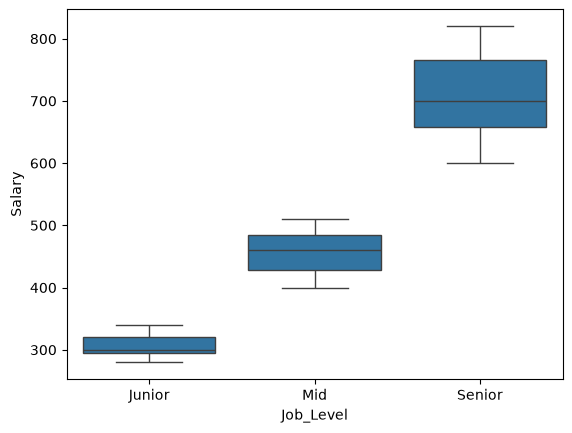

In [22]:
import seaborn as sns

sns.boxplot(x = 'Job_Level', y = 'Salary', data = df)

<Axes: xlabel='Department', ylabel='Salary'>

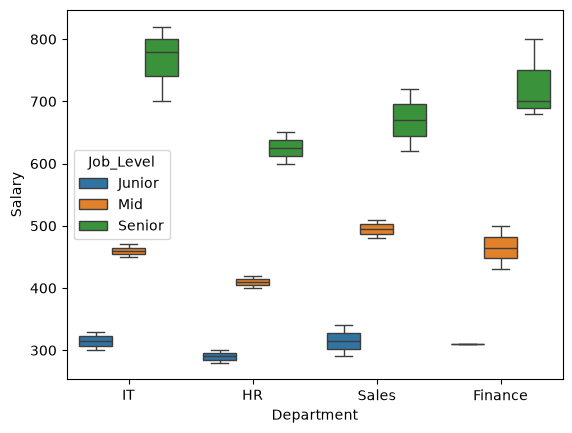

In [26]:
import seaborn as sns
sns.boxplot(x="Department", y="Salary", hue="Job_Level", data=df)

# Categorical vs Categorical

> Analyzes the relationship between two categorical variables.

Examples: `Gender vs Purchased`, `Membership vs Payment_Method`

## Main Goal

Determine whether two categorical variables are **associated/related**.

## Contingency Table

Shows frequency of combinations of two categorical variables.

```python
pd.crosstab(
    df["Membership"],
    df["Payment_Method"]
)
````

## Row Percentage

Percentage within each row/category.

```python
pd.crosstab(
    df["Membership"],
    df["Payment_Method"],
    normalize="index"
) * 100
```

## Column Percentage

```python
pd.crosstab(
    df["Membership"],
    df["Payment_Method"],
    normalize="columns"
) * 100
```

## Stacked Bar Chart

```python
pd.crosstab(
    df["Membership"],
    df["Payment_Method"]
).plot(
    kind="bar",
    stacked=True
)
```

## Chi-Square Test

Tests whether two categorical variables are independent.

H0 → Variables are independent

H1 → Variables are associated

```python
from scipy.stats import chi2_contingency

table = pd.crosstab(
    df["Membership"],
    df["Payment_Method"]
)

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)
```

### Interpretation

`p-value < 0.05` → Reject H0 → Evidence of association

`p-value >= 0.05` → Fail to reject H0 → Not enough evidence of association

## Cramér's V

Measures the **strength of association**.

`0 → No association`

`Closer to 1 → Stronger association`

## Important

**Chi-Square → Is there an association?**

**Cramér's V → How strong is the association?**

**Association ≠ Causation**

## Key Workflow

**Crosstab → Percentages → Visualization → Chi-Square → Strength → Interpretation**

```
```


In [27]:
import pandas as pd

data = {
    "Customer_ID": range(1, 31),

    "Membership": [
        "Bronze","Bronze","Silver","Gold","Gold",
        "Silver","Bronze","Gold","Silver","Gold",
        "Bronze","Silver","Gold","Gold","Bronze",
        "Silver","Gold","Bronze","Silver","Gold",
        "Gold","Silver","Bronze","Gold","Silver",
        "Bronze","Gold","Silver","Gold","Bronze"
    ],

    "Payment_Method": [
        "Cash","UPI","Card","UPI","Card",
        "UPI","Cash","UPI","Card","UPI",
        "Cash","Card","UPI","Card","Cash",
        "UPI","Card","Cash","UPI","Card",
        "UPI","Card","Cash","UPI","Card",
        "Cash","UPI","Card","UPI","Cash"
    ],

    "Device": [
        "Mobile","Mobile","Desktop","Mobile","Desktop",
        "Mobile","Desktop","Mobile","Mobile","Desktop",
        "Mobile","Desktop","Mobile","Desktop","Mobile",
        "Mobile","Desktop","Mobile","Desktop","Mobile",
        "Desktop","Mobile","Desktop","Mobile","Desktop",
        "Mobile","Desktop","Mobile","Desktop","Mobile"
    ]
}

df = pd.DataFrame(data)

In [29]:
pd.crosstab(df['Membership'],df['Payment_Method'])

Payment_Method,Card,Cash,UPI
Membership,,,
Bronze,0,8,1
Gold,4,0,8
Silver,6,0,3


In [31]:
pd.crosstab(
    df['Membership'],
    df['Payment_Method'],
    normalize ='index'
)*100

Payment_Method,Card,Cash,UPI
Membership,,,
Bronze,0.000000,88.888889,11.111111
Gold,33.333333,0.000000,66.666667
Silver,66.666667,0.000000,33.333333


In [32]:
pd.crosstab(
    df['Membership'],
    df['Payment_Method'],
    normalize ='columns'
)*100

Payment_Method,Card,Cash,UPI
Membership,,,
Bronze,0.0,100.0,8.333333
Gold,40.0,0.0,66.666667
Silver,60.0,0.0,25.000000


<Axes: xlabel='Membership'>

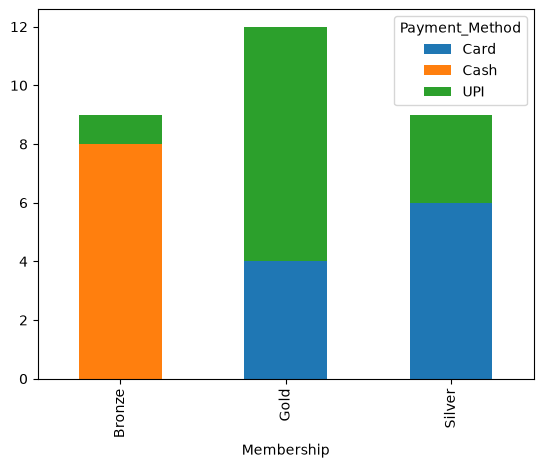

In [34]:
pd.crosstab(
    df['Membership'],
    df['Payment_Method'],
).plot(kind = 'bar',stacked = True)

In [35]:
from scipy.stats import chi2_contingency

table = pd.crosstab(
    df['Membership'],
    df['Payment_Method'],
)

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 28.777777777777775
p-value: 8.673456781334208e-06


In [38]:
expected

array([[3. , 2.4, 3.6],
       [4. , 3.2, 4.8],
       [3. , 2.4, 3.6]])

<Axes: xlabel='Membership'>

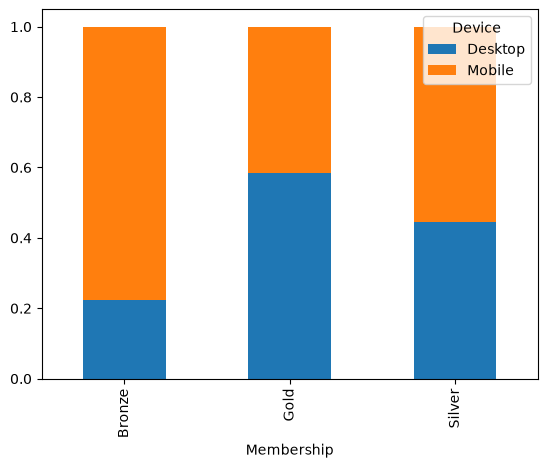

In [40]:
pd.crosstab(
    df['Membership'],
    df['Device'],
    normalize ='index'
).plot(kind = 'bar', stacked = True)